# Semi Gradient n-step Sarsa

In [6]:
from algorithms.sgns_sarsa.n_step_sarsa import SGNStepSARSA, Config
from mdp.base_config import BaseConfig
import numpy as np
import matplotlib.pyplot as plt
from mdp.cats_v_monsters.cats_vs_monsters import CatsVMonstersMDP
from algorithms.value_iteration.value_iteration import ValueIteration
from mdp.mdp_utils import display_value_function, display_policy
base_config = BaseConfig(42)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Cats vs Monsters MDP

### Find the optimal value function and policy using Value Iteration

In [7]:
optimal_mdp = CatsVMonstersMDP()
optimal_vi = ValueIteration(mdp=optimal_mdp)
optimal_rh = optimal_vi.run_value_iteration()
optimal_vf, optimal_policy = optimal_rh[len(optimal_rh)]
print("Optimal Value Function:")
display_value_function(optimal_mdp, optimal_vf)
print("Optimal Policy:")
display_policy(optimal_mdp, optimal_policy)

Optimal Value Function:
2.6638	2.9969	2.8117	3.6671	4.8497	
2.9713	3.5101	4.0819	4.8497	7.1648	
2.5936	0.0000	0.0000	0.0000	8.4687	
2.0992	1.0849	0.0000	8.6097	9.5269	
1.0849	4.9465	8.4687	9.5269	0.0000	
Optimal Policy:
→	↓	←	↓	↓	
→	→	→	→	↓	
↑	F	F	F	↓	
↑	←	F	↓	↓	
↑	→	→	→	G	


In [85]:
cvm = CatsVMonstersMDP()
config = Config(q_init_choice='equal', optimistic_value=10, action_selection='softmax', epsilon=0.1)
sarsa = SGNStepSARSA(cvm, optimal_vf=optimal_vf, gamma=0.2)

In [103]:
reward = sarsa.run_episode(alpha=0.001, n_steps=2, verbose=True)
print(f"Total reward in one episode: {reward}")

state: (0, 1), action: down
Total reward in one episode: -32.00000000000001


In [104]:
points_metadata, mse_metadata = sarsa.run_20_times(num_episodes=10000, alpha=0.1, n_steps=5)

Running SARSA Episodes:   0%|          | 0/20 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

...

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

In [105]:
points_metadata_np = np.array(points_metadata, dtype=object)
print(points_metadata_np.shape)
mean_steps = np.mean(points_metadata_np, axis=0)
print(mean_steps.shape)

(20, 10000)
(10000,)


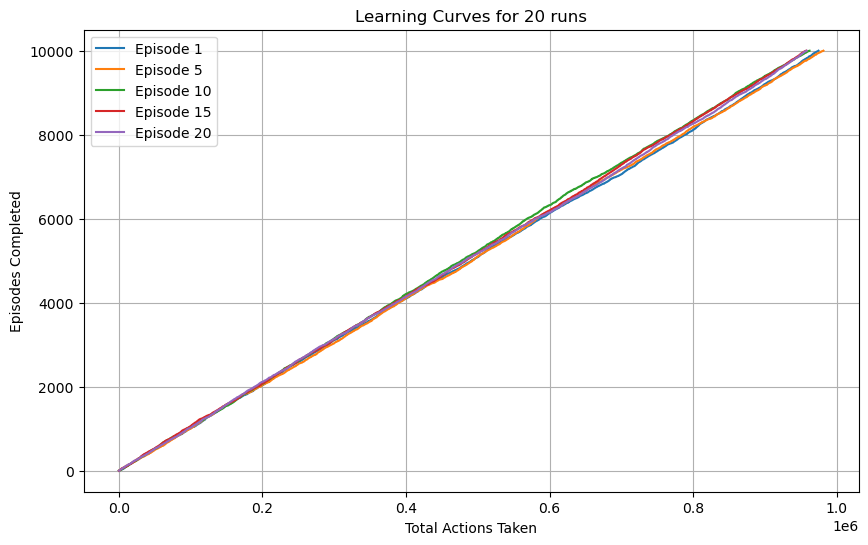

In [106]:
episodes = np.arange(1, mean_steps.shape[0] + 1)
plt.figure(figsize=(10, 6))
for run in [0, 4, 9, 14, 19]:
    plt.plot(points_metadata[run], episodes, label=f"Episode {run+1}")
plt.xlabel("Total Actions Taken")
plt.ylabel("Episodes Completed")
plt.title("Learning Curves for 20 runs")
plt.grid(True)
plt.legend()
plt.show()

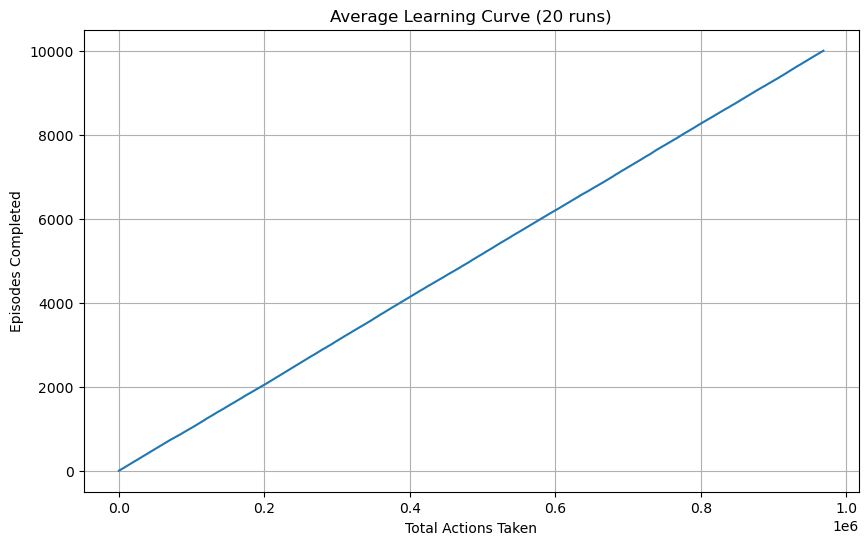

In [107]:
plt.figure(figsize=(10, 6))
episodes = np.arange(1, mean_steps.shape[0] + 1)
plt.plot(mean_steps, episodes)
plt.xlabel("Total Actions Taken")
plt.ylabel("Episodes Completed")
plt.title("Average Learning Curve (20 runs)")
plt.grid(True)
plt.show()

In [108]:
mse_metadata_np = np.array(mse_metadata, dtype=object)
print(mse_metadata_np.shape)
mean_mse = np.mean(mse_metadata_np, axis=0)
print(mean_mse.shape)

(20, 10000)
(10000,)


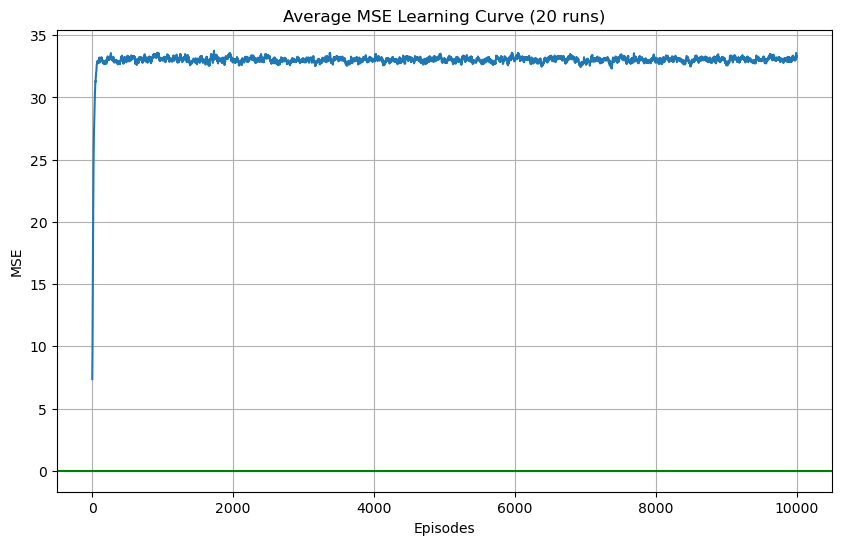

In [109]:
plt.figure(figsize=(10, 6))
episodes = np.arange(1, mse_metadata_np.shape[1] + 1)
plt.plot(episodes, mean_mse)
plt.axhline(y=0, color='g', label='0 MSE')
plt.xlabel("Episodes")
plt.ylabel("MSE")
plt.title("Average MSE Learning Curve (20 runs)")
plt.grid(True)
plt.show()